In [1]:
import os

os.environ.pop("PYTHONPATH", None) 
os.environ.pop("PYTHONHOME", None) 

In [2]:
%load_ext autoreload
%autoreload 2

import scripts.snapshot_loader as sl
from matplotlib import pyplot as plt
from matplotlib.colors import LogNorm
from matplotlib.cm import ScalarMappable
from tqdm import tqdm
import numpy as np
import os

os.environ["JAX_PLATFORM_NAME"] = "cpu"   # or "gpu" (for CUDA GPU builds)

EXP_FOLDER = "data/interp_supervised_0_1/interp_6/snapshots_P"


In [3]:
def plot_dynamics(steps, alpha, eval_function, eps_values, P=None, A=None, rgb=None):
    # eps_values = np.logspace(2.5, 3, 20)
    # eps_values = np.array([500])

    cmap = plt.get_cmap("viridis")
    norm = LogNorm(vmin=eps_values.min(), vmax=eps_values.max())

    fig, ax = plt.subplots()

    for eps in tqdm(eps_values):
        cnts = eval_function(P=P, A=A, rgb=rgb, eps=eps)
        ax.plot((steps / (250 * 60)), cnts, color=cmap(norm(eps)), lw=1)

    sm = ScalarMappable(norm=norm, cmap=cmap)
    sm.set_array([])
    fig.colorbar(sm, ax=ax, label="eps")
    plt.title(f'$\\alpha = {alpha}$')
    plt.show()


import numpy as np
import matplotlib.pyplot as plt

def make_palette(n_labels, seed=0):
    rng = np.random.default_rng(seed)
    pal = rng.integers(0, 256, size=(n_labels, 3), dtype=np.uint8)
    pal[0] = 0  # label 0 = void = black
    return pal

def visualize_rgb_and_labels(rgb_u8, labels, palette=None, seed=0, figsize=(10, 5)):
    """
    rgb_u8:  (H,W,3) uint8 (or anything np.asarray can convert)
    labels:  (H,W)   int, 0..K
    palette: (K+1,3) uint8, optional. If None, a deterministic random palette is created.
    Returns: palette used (uint8).
    """
    rgb_u8 = np.asarray(rgb_u8)
    labels = np.asarray(labels)

    if palette is None:
        palette = make_palette(int(labels.max()) + 1, seed=seed)
    else:
        palette = np.asarray(palette)

    label_rgb = palette[labels]  # (H,W,3) uint8

    fig, ax = plt.subplots(1, 2, figsize=figsize)
    ax[0].imshow(rgb_u8)
    ax[0].set_title("RGB")
    ax[0].axis("off")

    ax[1].imshow(label_rgb)
    ax[1].set_title("Labels")
    ax[1].axis("off")

    plt.tight_layout()
    plt.show()
    return palette



In [4]:
import importlib.metadata as md
from pathlib import Path

dists = sorted(md.distributions(), key=lambda d: (d.metadata.get("Name") or "").lower())
for d in dists:
    name = d.metadata.get("Name") or d.metadata.get("Summary") or "UNKNOWN"
    loc = Path(d.locate_file("")).resolve()   # typically the env's site-packages
    print(f"{name}\t{loc}")

absl-py	/home/coder/.conda/envs/torchjax/lib/python3.11/site-packages
aiofiles	/home/coder/.conda/envs/torchjax/lib/python3.11/site-packages
annotated-types	/home/coder/.conda/envs/torchjax/lib/python3.11/site-packages
antlr4-python3-runtime	/home/coder/.conda/envs/torchjax/lib/python3.11/site-packages
anyio	/home/coder/.conda/envs/torchjax/lib/python3.11/site-packages
appnope	/home/coder/.conda/envs/torchjax/lib/python3.11/site-packages
argon2-cffi	/home/coder/.conda/envs/torchjax/lib/python3.11/site-packages
argon2-cffi-bindings	/home/coder/.conda/envs/torchjax/lib/python3.11/site-packages
arrow	/home/coder/.conda/envs/torchjax/lib/python3.11/site-packages
asttokens	/home/coder/.conda/envs/torchjax/lib/python3.11/site-packages
async-lru	/home/coder/.conda/envs/torchjax/lib/python3.11/site-packages
attrs	/home/coder/.conda/envs/torchjax/lib/python3.11/site-packages
babel	/home/coder/.conda/envs/torchjax/lib/python3.11/site-packages
beautifulsoup4	/home/coder/.conda/envs/torchjax/lib/p

In [5]:
import numpy as np
import torch

steps, P, A, rgb = sl.load_snapshots(
        EXP_FOLDER,
        start_sec=28*60,
        end_sec=29*60
    )
sl.render_snapshots_to_video(P, 'try.mp4', rgb=rgb)

In [6]:
b = 50
a = 114
As = A[:15, b+10:a+10, b:a]
Ps = P[:15, b+10:a+10, b:a]
rgbs = rgb[:15, b+10:a+10, b:a]

## Some stuff

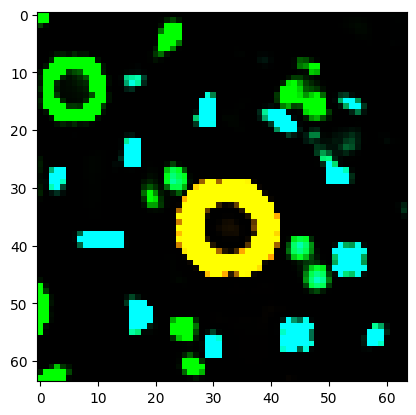

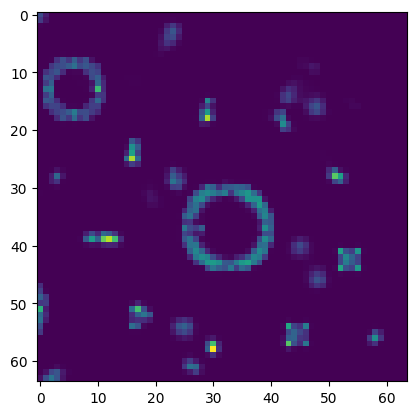

In [33]:
Asd = As[0].sum(axis=-1)
plt.imshow(Asd / Asd.max()  )

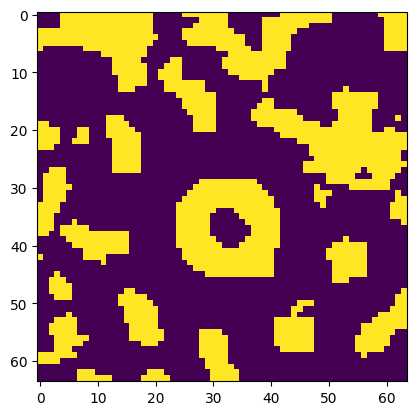

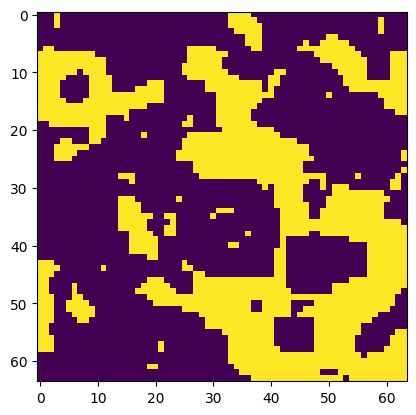

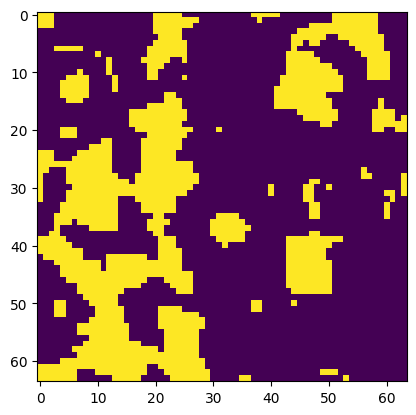

In [42]:
plt.imshow((As[0].argmax(axis=-1) == 0).astype(np.int32))
plt.show()
plt.imshow((As[0].argmax(axis=-1) == 1).astype(np.int32))
plt.show()
plt.imshow((As[0].argmax(axis=-1) == 2).astype(np.int32))
plt.show()

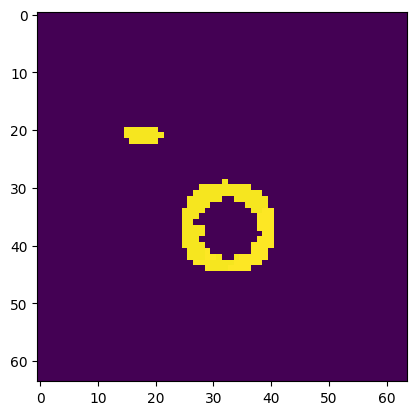

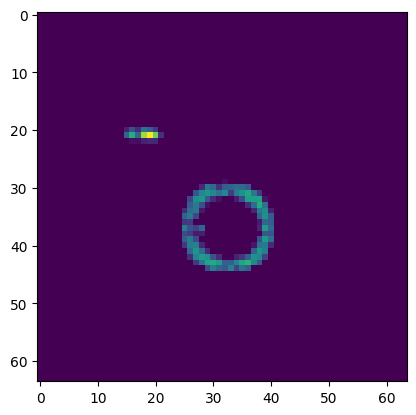

In [14]:
yellow_genom = Ps[0, 32, 32]
blue_genom = Ps[0, 47, 55]

mask = ( (((Ps[0] - yellow_genom)**2).sum(axis=-1)**0.5 < 10)  | (((Ps[0] - blue_genom)**2).sum(axis=-1)**0.5 < 16.5))[..., None]


patch_1 = np.full(mask.shape, True)
patch_1[10:15, 10:20] = False
mask = mask & patch_1

patch_2 = np.full(mask.shape, True)
patch_2[0:25, 45:60] = False
mask = mask & patch_2

patch_2 = np.full(mask.shape, True)
patch_2[0:25, 45:60] = False
mask = mask & patch_2

patch_3 = np.full(mask.shape, True)
patch_3[20:35, 0:8] = False
mask = mask & patch_3

patch_3 = np.full(mask.shape, True)
patch_3[50:60, 55:64] = False
mask = mask & patch_3

mask = mask & (As[0].sum(-1) > 1e-1)[..., None]


# remove yellow center
# patch_4 = np.full(mask.shape, True)
# patch_4[25:45, 20:45] = False
# mask = mask & patch_4

#remove all blues except one


Af = mask * As[0]
Pf = mask * Ps[0]
rgbf = mask * rgbs[0]

Af_blue = Af[30:45, 5:20]
Pf_blue = Pf[30:45, 5:20]
Pf_blue[Pf_blue.sum(-1) != 0] = yellow_genom

rgbf_blue = rgbf[30:45, 5:20]


patch_4 = np.full(mask.shape, False)
patch_4[25:45, 20:45] = True
mask = mask & patch_4


Af = mask * As[0]
Pf = mask * Ps[0]
rgbf = mask * rgbs[0]

c = 12
Af[c:15+c, c:15+c] = Af_blue
Pf[c:15+c, c:15+c] = Pf_blue
rgbf[c:15+c, c:15+c] = rgbf_blue

plt.imshow(Pf.sum(-1))
plt.show()
plt.imshow(Af.sum(-1))
plt.show()


In [1]:
plt.imshow(rgbf)

NameError: name 'plt' is not defined

## Kernel analysis

ParameterReshaper: 110 parameters detected for optimization.
[0, 0, 0, 1, 1, 1, 2, 2, 2]


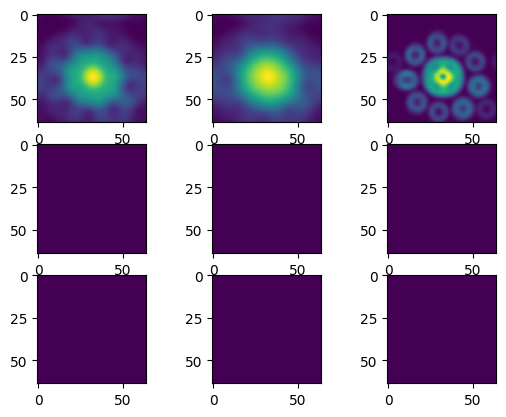

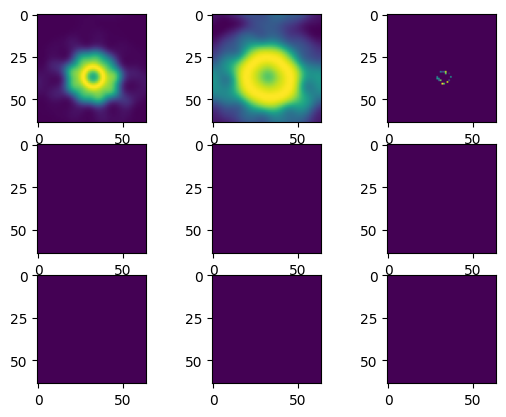

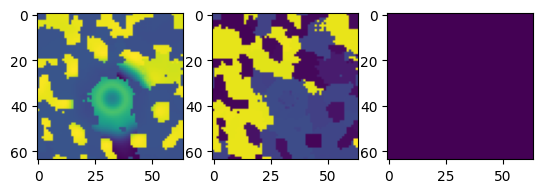

(64, 64, 2, 3)


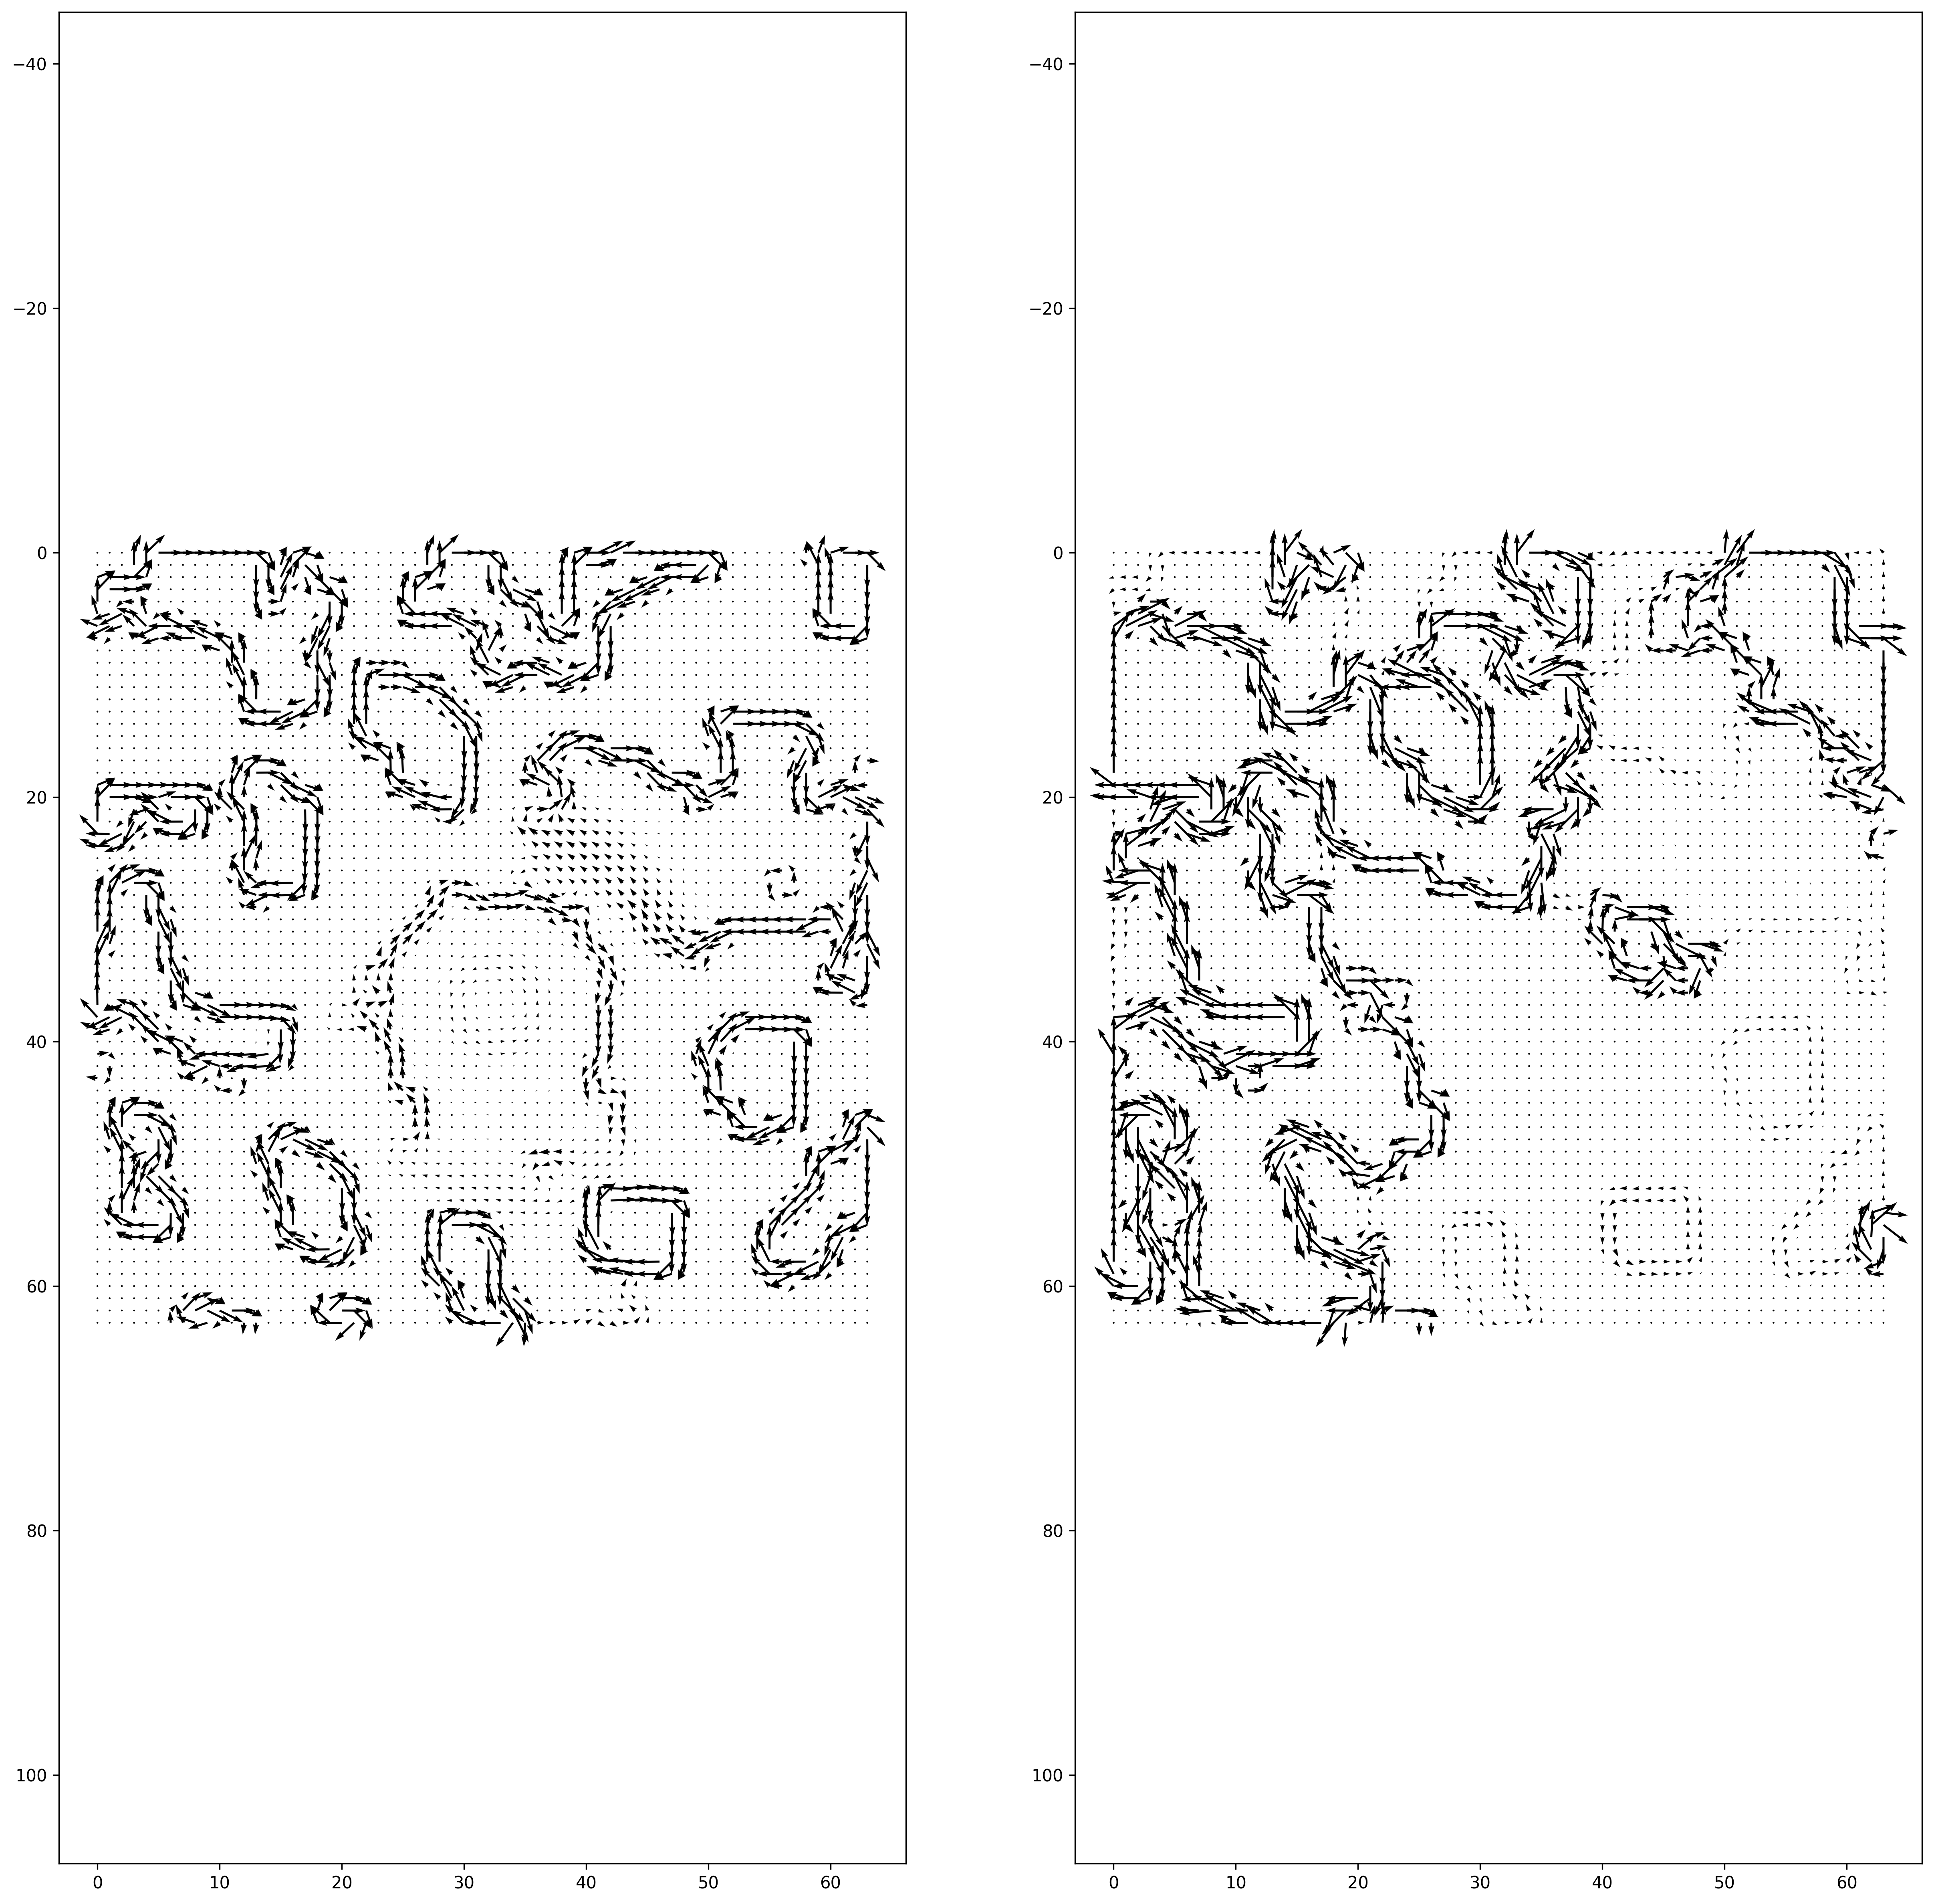

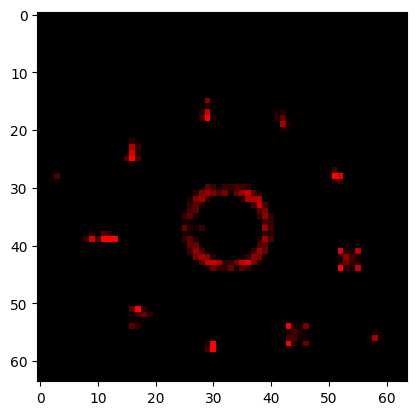

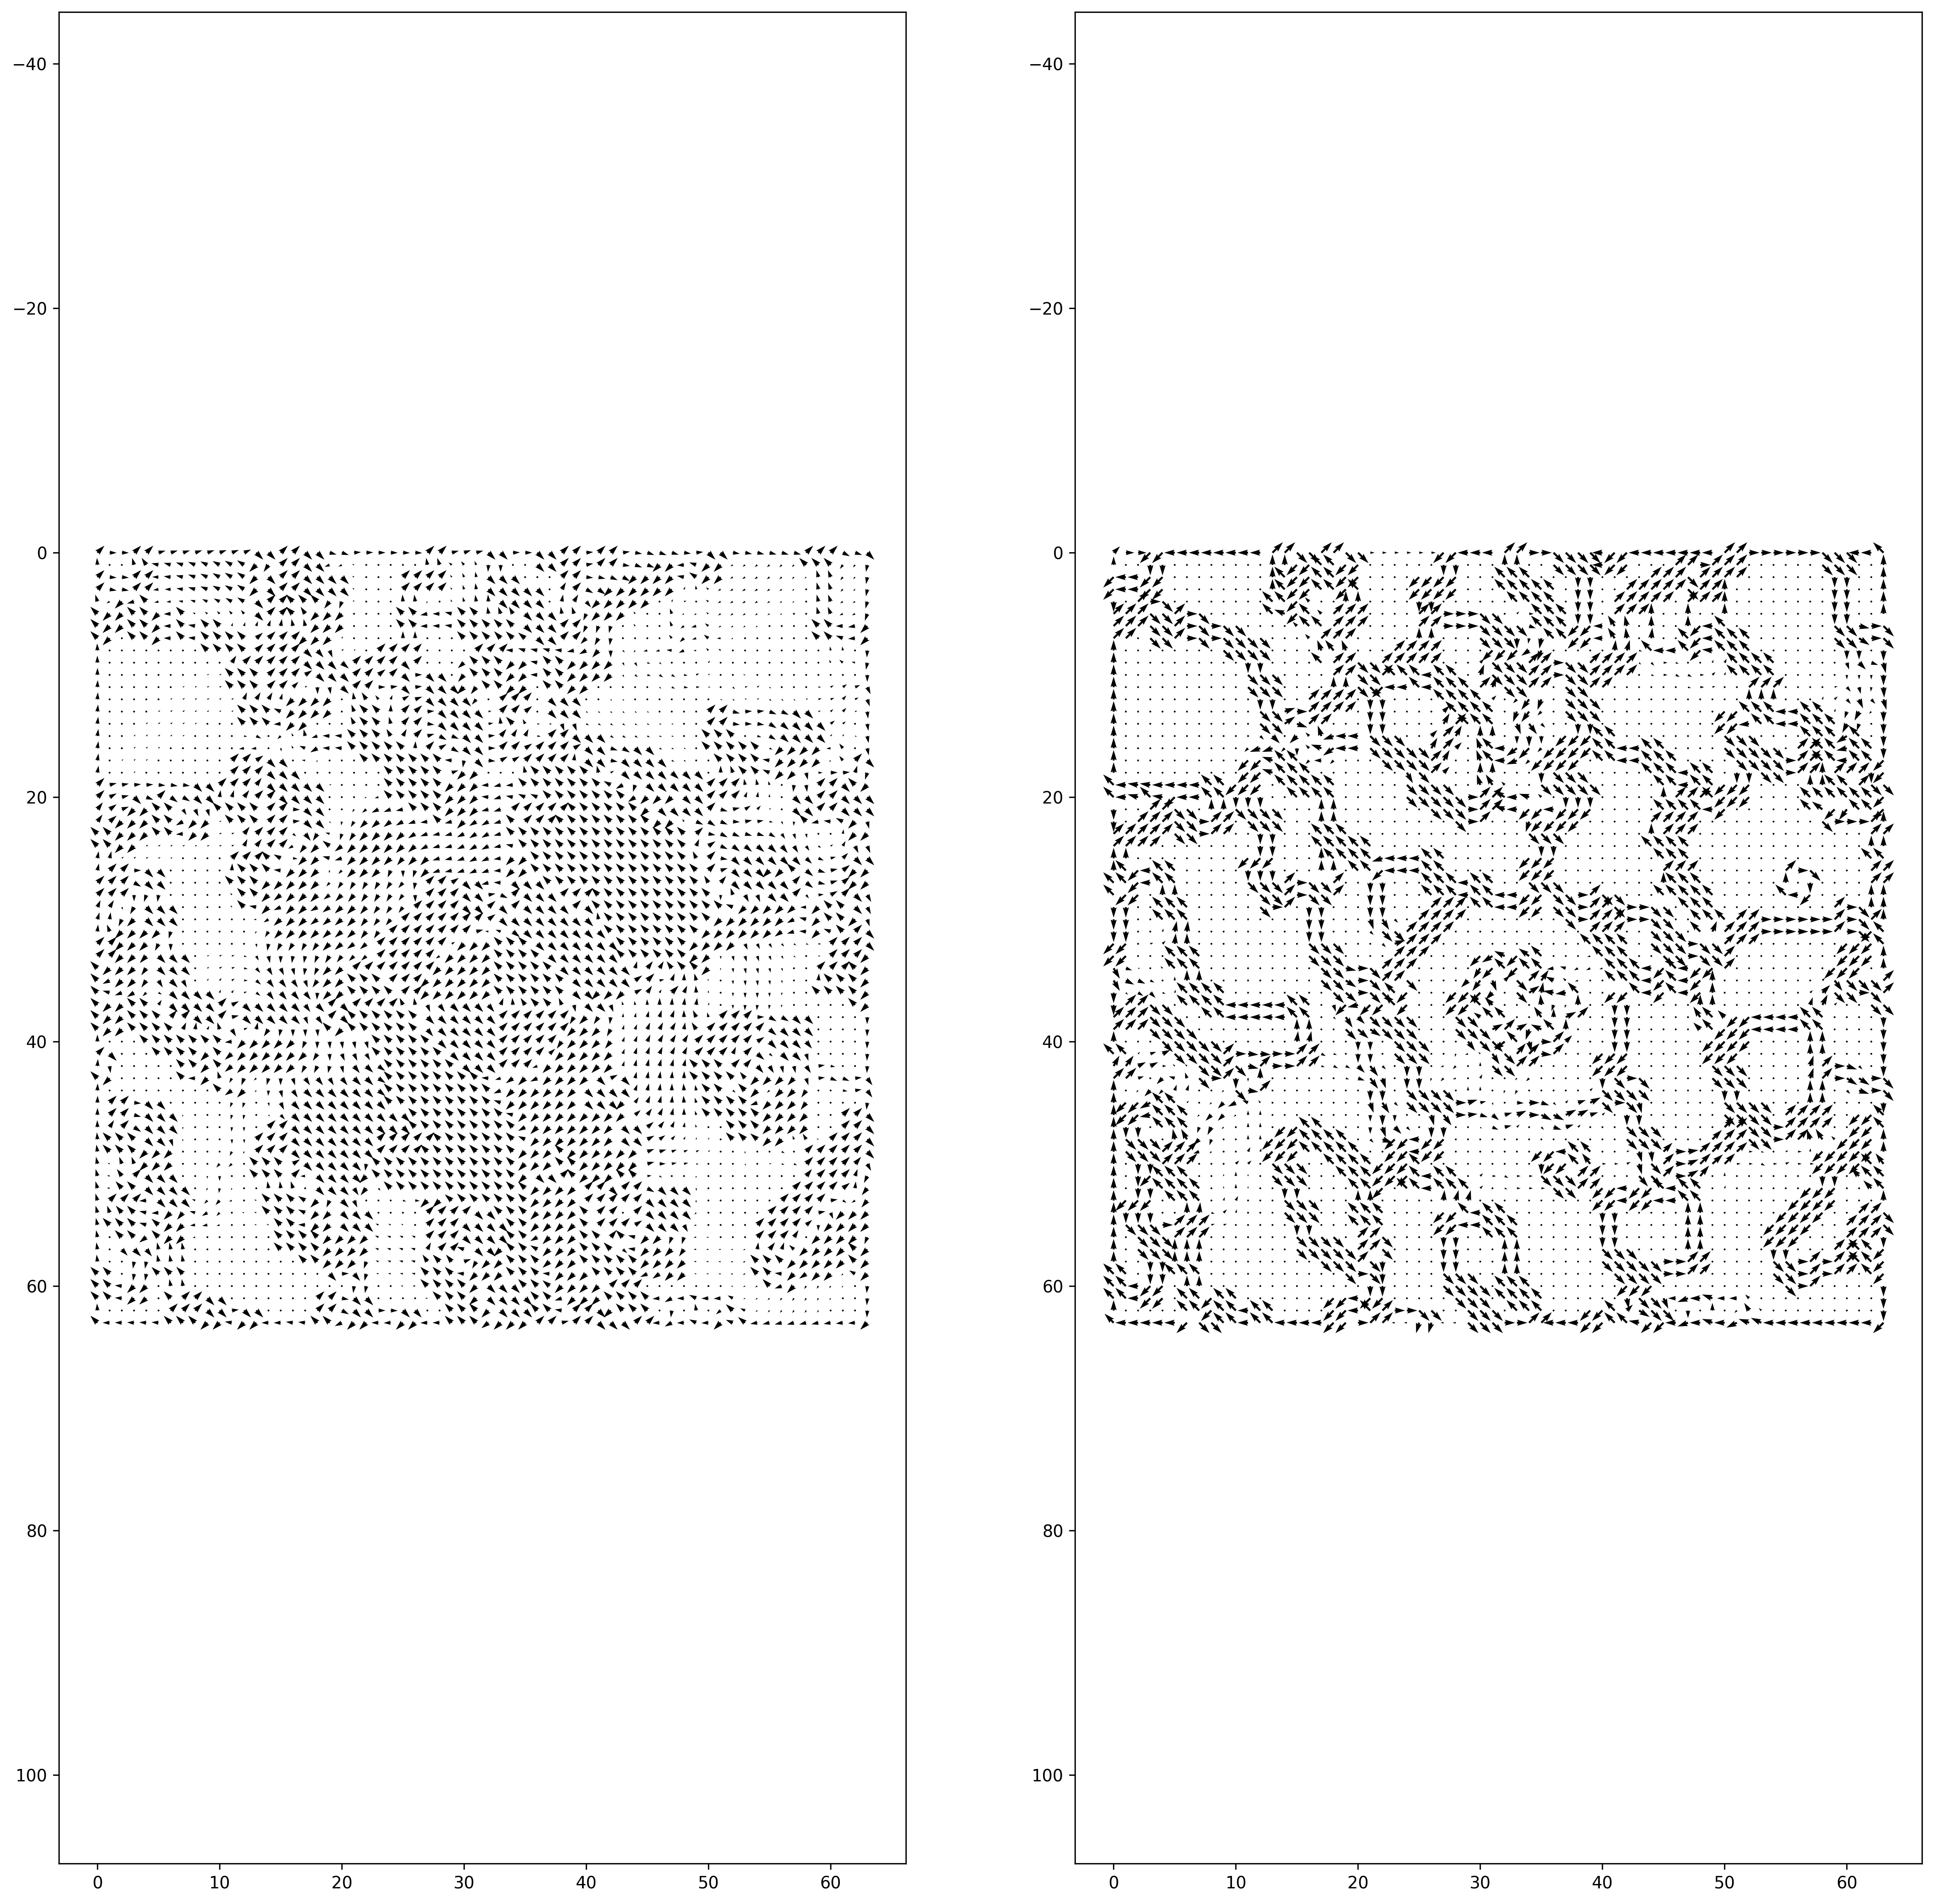

U shape: (64, 64, 3) V shape: (64, 64, 2, 3) F shape: (64, 64, 2, 3)


In [8]:
import pickle
import jax
import jax.numpy as jnp
import numpy as np

from substrates import create_substrate, FlattenSubstrateParameters
from substrates.lenia_flow.utils import growth, sobel  # добавили sobel

# --- user inputs ---
ckpt_path = "data/interp_supervised_0_1/interp_6/best.pkl"        # путь до чекпоинта
A_np = As[0]  # ваш numpy (H, W, C)
P_np = Ps[0]  # ваш numpy (H, W, k)

A_np[..., 1:3] = 0
P_np[..., 3:] = 0

# --- load params ---
params_obj = pickle.load(open(ckpt_path, "rb"))
params_flat = params_obj[0] if isinstance(params_obj, tuple) else params_obj
params_flat = jnp.asarray(params_flat)

# --- substrate/state для fK,m,s ---
fl = create_substrate("lenia_flow")
fl = FlattenSubstrateParameters(fl)
rng = jax.random.PRNGKey(0)
state = fl.init_state(rng, params_flat)
cfg = fl.substrate.cfg
fK = state["fK"]
m = state["m"]
s = state["s"]
c0 = cfg.c0
c1 = cfg.c1

print(c0)
# --- ваши A, P ---
A = jnp.asarray(A_np)
P = jnp.asarray(P_np)

# --- U (potential) ---
fA = jnp.fft.fft2(A, axes=(0, 1))
fAk = fA[:, :, c0]
U = jnp.real(jnp.fft.ifft2(fK * fAk, axes=(0, 1)))
fig, ax = plt.subplots(3, 3)
for i in range(9):
    ax[i // 3, i % 3 ].imshow(U[:, :, i])
plt.show()

U = growth(U, m, s)

fig, ax = plt.subplots(3, 3)
for i in range(9):
    ax[i // 3, i % 3 ].imshow(U[:, :, i])
plt.show()

U = U * P

U = jnp.dstack([U[:, :, c1[c]].sum(axis=-1) for c in range(cfg.C)])  # (H, W, C)


fig, ax = plt.subplots(1, 3)
for i in range(3):
    ax[i % 3].imshow(U[:, :, i])
plt.show()
# --- v(x,t): flow field (H, W, 2, C) ---
V = sobel(U)




print(V.shape)
fig, ax = plt.subplots(1, 2, figsize=(20,20), dpi=300)
for i in range(2):
    ax[i].quiver(V[:, :, 0, i], V[:, :, 1, i])
    ax[i].invert_yaxis(); ax[i].axis("equal")

plt.show()

C_grad = sobel(A.sum(axis=-1, keepdims=True))
alpha = jnp.clip((A[:, :, None, :] / 2) ** 2, 0.0, 1.0)
plt.imshow(alpha[:, :, 0, :])
plt.show()
mag = cfg.dd - cfg.sigma
F = jnp.clip(V * (1 - alpha) - C_grad * alpha, -mag, mag)

fig, ax = plt.subplots(1, 2, figsize=(20,20), dpi=300)
for i in range(2):
    ax[i].quiver(F[:, :, 0, i], F[:, :, 1, i])
    ax[i].invert_yaxis(); ax[i].axis("equal")

plt.show()

Us = np.array(U)
Vs = np.array(V)
Fs = np.array(F)
print("U shape:", Us.shape, "V shape:", Vs.shape, "F shape:", Fs.shape)


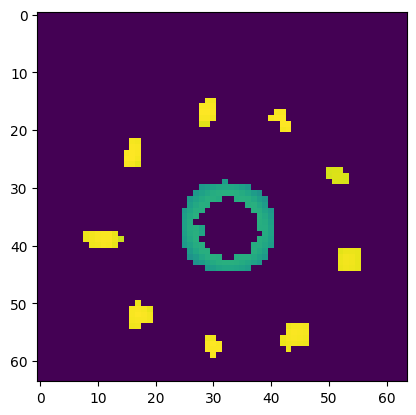

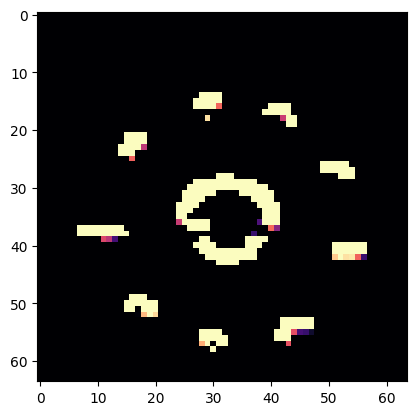

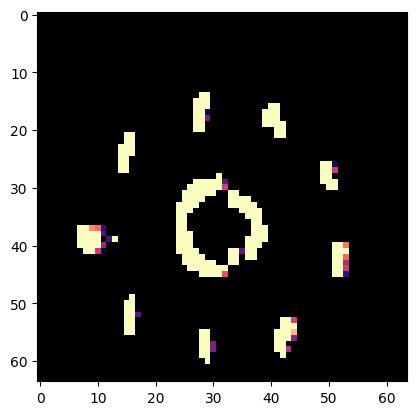

In [37]:
plt.imshow(Us[:, :, 0])
plt.show()
plt.imshow(Fs[:, :, 0, 0] / Fs[:, :, 0, 0].max(), cmap="magma", vmin=0, vmax=1)
# plt.imshow(rgbf, alpha=0.35)
plt.show()
plt.imshow(Fs[:, :, 1, 0] / Fs[:, :, 1, 0].max(), cmap="magma", vmin=0, vmax=1)
# plt.imshow(rgbf, alpha=0.35)
plt.show()

In [67]:
import numpy as np
import jax
import jax.numpy as jnp
import jax.random as jr

SOBEL_KX = jnp.array([[1.0, 0.0, -1.0],
                      [2.0, 0.0, -2.0],
                      [1.0, 0.0, -1.0]], dtype=jnp.float32)
SOBEL_KY = jnp.transpose(SOBEL_KX)

def _sobel_conv(A, kernel):
    # A: (H,W,C) -> (H,W,C), depthwise conv: same 3x3 kernel per channel
    _, _, C = A.shape
    lhs = A[jnp.newaxis, ...]              # (1,H,W,C)
    ker = kernel[:, :, None, None]         # (3,3,1,1)
    ker = jnp.tile(ker, (1, 1, 1, C))      # (3,3,1,C)  <-- ключевой фикс
    out = jax.lax.conv_general_dilated(
        lhs, ker,
        window_strides=(1, 1),
        padding="SAME",
        dimension_numbers=("NHWC", "HWIO", "NHWC"),
        feature_group_count=C,
    )
    return out[0]

@jax.jit
def sobel(A):
    sx = _sobel_conv(A, SOBEL_KX)
    sy = _sobel_conv(A, SOBEL_KY)
    return jnp.concatenate((sy[:, :, None, :], sx[:, :, None, :]), axis=2)  # (H,W,2,C)


# ---------- precomputed radial projector (jit-safe) ----------

def make_radial_projector(H, W, center=None):
    if center is None:
        cx = (H - 1) / 2.0
        cy = (W - 1) / 2.0
    else:
        cx, cy = center

    ii, jj = np.indices((H, W))
    r = np.sqrt((ii - cx) ** 2 + (jj - cy) ** 2)
    rb = np.floor(r).astype(np.int32)
    rmax = int(rb.max()) + 1
    rb = np.clip(rb, 0, rmax - 1)

    rb_j = jnp.asarray(rb, dtype=jnp.int32)

    @jax.jit
    def proj(field):
        # field: (H,W,D)
        D = field.shape[-1]
        sums = jnp.zeros((rmax, D), dtype=field.dtype).at[rb_j].add(field)
        cnts = jnp.zeros((rmax,), dtype=field.dtype).at[rb_j].add(1.0)
        prof = sums / cnts[:, None]
        field_rad = prof[rb_j]
        return field_rad, prof

    return proj, rmax


# ---------- mean-field RT step builder (dd fixed here) ----------

def make_meanfield_stepper(fK, m, s, c0, c1, dt, dd, sigma, center=None):
    """
    Возвращает jitted step(A,P) для mean-field аналога stoch.
    dd фиксируется в замыкании -> нет ConcretizationTypeError.
    """
    H, W, k = fK.shape
    c0 = jnp.asarray(c0, dtype=jnp.int32)
    c1_idx = tuple(jnp.asarray(lst, dtype=jnp.int32) for lst in c1)

    m = jnp.asarray(m, dtype=jnp.float32)
    s = jnp.asarray(s, dtype=jnp.float32)

    if center is None:
        center = ((H - 1) / 2.0, (W - 1) / 2.0)

    radial_proj, _ = make_radial_projector(H, W, center=center)

    # pos как в вашем RT: pos=(y,x)+0.5
    ii, jj = np.indices((H, W))
    pos_np = np.stack([jj, ii], axis=-1).astype(np.float32) + 0.5
    pos = jnp.asarray(pos_np)

    # список сдвигов Δ = (dx,dy) длины S=(2dd+1)^2
    sh = np.array([(dx, dy) for dx in range(-dd, dd + 1) for dy in range(-dd, dd + 1)],
                  dtype=np.int32)
    sh = jnp.asarray(sh)  # (S,2)
    ma = float(dd - sigma)  # внутренний клип по смещению

    @jax.jit
    def compute_flow(A, P):
        # A: (H,W,C), P: (H,W,k)
        fA = jnp.fft.fft2(A, axes=(0, 1))          # (H,W,C) complex
        fAk = fA[:, :, c0]                         # (H,W,k)
        u = jnp.real(jnp.fft.ifft2(fK * fAk, axes=(0, 1)))  # (H,W,k)
        g = growth(u, m, s)                        # (H,W,k)
        tmp = g * P                                # (H,W,k)

        U = jnp.stack([tmp[:, :, c1_idx[c]].sum(axis=-1) for c in range(A.shape[-1])], axis=-1)  # (H,W,C)

        F = sobel(U)                               # (H,W,2,C)
        C_grad = sobel(A.sum(axis=-1, keepdims=True))  # (H,W,2,1)

        alpha = jnp.clip((A[:, :, None, :] / 2.0) ** 2, 0.0, 1.0)  # (H,W,1,C)
        mag = dd - sigma
        F = jnp.clip(F * (1.0 - alpha) - C_grad * alpha, -mag, mag)
        return F  # (H,W,2,C)

    @jax.jit
    def reintegrate_meanfield(A, P, F):
        # F: (H,W,2,C) -> (H,W,C,2)
        Fc = jnp.transpose(F, (0, 1, 3, 2))
        mu = pos[:, :, None, :] + jnp.clip(dt * Fc, -ma, ma)  # (H,W,C,2)

        A_acc = jnp.zeros_like(A)
        P_num = jnp.zeros_like(P)
        W_den = jnp.zeros((H, W, 1), dtype=A.dtype)

        def body(carry, dxy):
            A_acc, P_num, W_den = carry
            dx, dy = dxy[0], dxy[1]

            Ar = jnp.roll(A, (dx, dy), axis=(0, 1))       # (H,W,C)
            Pr = jnp.roll(P, (dx, dy), axis=(0, 1))       # (H,W,k)
            mur = jnp.roll(mu, (dx, dy), axis=(0, 1))     # (H,W,C,2)

            d = pos[:, :, None, :] - mur                  # (H,W,C,2)
            d0 = d[..., 0]  # along y (width W)
            d1 = d[..., 1]  # along x (height H)

            # тор-метрика (минимальный модуль по модулю W/H)
            d0 = (d0 + (W / 2.0)) % W - (W / 2.0)
            d1 = (d1 + (H / 2.0)) % H - (H / 2.0)

            dpmu = jnp.stack([jnp.abs(d0), jnp.abs(d1)], axis=-1)      # (H,W,C,2)
            sz = 0.5 - dpmu + sigma                                     # (H,W,C,2)

            cap = jnp.minimum(1.0, 2.0 * sigma)
            clipped = jnp.clip(sz, 0.0, cap)
            area = (clipped[..., 0] * clipped[..., 1]) / (4.0 * sigma ** 2)  # (H,W,C)

            nA = Ar * area                                              # (H,W,C)
            w = nA.sum(axis=-1, keepdims=True)                          # (H,W,1)

            A_acc = A_acc + nA
            P_num = P_num + Pr * w
            W_den = W_den + w
            return (A_acc, P_num, W_den), None

        (A_acc, P_num, W_den), _ = jax.lax.scan(body, (A_acc, P_num, W_den), sh)
        P_next = jnp.where(W_den > 0.0, P_num / (W_den + 1e-12), P)
        return A_acc, P_next

    @jax.jit
    def step(A, P):
        F = compute_flow(A, P)
        A2, P2 = reintegrate_meanfield(A, P, F)

        A2 = jnp.clip(A2, 0.0, 1.0)
        P2 = jnp.clip(P2, 0.0, 1.0)

        A2, Aprof = radial_proj(A2)
        P2, Pprof = radial_proj(P2)
        return A2, P2, Aprof, Pprof

    return step


# ---------- stationary finder for (A,P) ----------

def find_radial_stationary_AP(
    step_fn,
    H, W, C, k,
    steps=4000,
    check_every=50,
    tol=1e-6,
    n_inits=6,
    seed=0,
):
    key = jr.PRNGKey(seed)
    sols = []

    for _ in range(n_inits):
        key, kA, kP = jr.split(key, 3)
        A = jr.uniform(kA, (H, W, C), minval=0.0, maxval=1.0)
        P = jr.uniform(kP, (H, W, k), minval=0.0, maxval=1.0)

        A_prev, P_prev = A, P
        for t in tqdm(range(steps)):
            A, P, Aprof, Pprof = step_fn(A, P)

            if (t + 1) % check_every == 0:
                dA = jnp.linalg.norm((A - A_prev).reshape(-1))
                dP = jnp.linalg.norm((P - P_prev).reshape(-1))
                nA = jnp.linalg.norm(A_prev.reshape(-1)) + 1e-12
                nP = jnp.linalg.norm(P_prev.reshape(-1)) + 1e-12
                if (dA / nA < tol) and (dP / nP < tol):
                    break
                A_prev, P_prev = A, P

        sols.append({"A2d": A, "P2d": P, "Aprof": Aprof, "Pprof": Pprof})

    return sols


# входы из вашей системы
fK = state["fK"]          # (H,W,k) complex
m  = state["m"]           # (k,)
s  = state["s"]           # (k,)
c0 = cfg.c0               # (k,) python list/array
c1 = cfg.c1               # list-of-lists, len=C
dt, dd, sigma = cfg.dt, cfg.dd, cfg.sigma

H, W, k = fK.shape
C = cfg.C

step_fn = make_meanfield_stepper(fK, m, s, c0, c1, dt=dt, dd=int(dd), sigma=float(sigma))
sols = find_radial_stationary_AP(step_fn, H, W, C, k, n_inits=8, steps=5000)

# например, посмотреть радиальный стационар для P:
Pprof0 = sols[0]["Pprof"]   # (rmax, k)



  0%|          | 0/5000 [00:00<?, ?it/s]

100%|██████████| 5000/5000 [01:46<00:00, 47.13it/s]


In [7]:
import pickle
import jax
import jax.numpy as jnp
import numpy as np

from substrates import create_substrate, FlattenSubstrateParameters
from substrates.lenia_flow.utils import growth, sobel  # добавили sobel

# --- user inputs ---
ckpt_path = "data/interp_supervised_0_1/interp_6/best.pkl"        # путь до чекпоинта
A_np = Af  # ваш numpy (H, W, C)
P_np = Pf  # ваш numpy (H, W, k)

A_np[..., 1:3] = 0
P_np[..., 3:] = 0

# --- load params ---
params_obj = pickle.load(open(ckpt_path, "rb"))
params_flat = params_obj[0] if isinstance(params_obj, tuple) else params_obj
params_flat = jnp.asarray(params_flat)

# --- substrate/state для fK,m,s ---
fl = create_substrate("lenia_flow")
fl = FlattenSubstrateParameters(fl)
rng = jax.random.PRNGKey(0)
state = fl.init_state(rng, params_flat)
cfg = fl.substrate.cfg
fK = state["fK"]
m = state["m"]
s = state["s"]
c0 = cfg.c0
c1 = cfg.c1

print(c0)
# --- ваши A, P ---
A = jnp.asarray(A_np)
P = jnp.asarray(P_np)

# --- U (potential) ---
fA = jnp.fft.fft2(A, axes=(0, 1))
fAk = fA[:, :, c0]
U = jnp.real(jnp.fft.ifft2(fK * fAk, axes=(0, 1)))
fig, ax = plt.subplots(3, 3)
for i in range(9):
    ax[i // 3, i % 3 ].imshow(U[:, :, i])
plt.show()

U = growth(U, m, s)

fig, ax = plt.subplots(3, 3)
for i in range(9):
    ax[i // 3, i % 3 ].imshow(U[:, :, i])
plt.show()

U = U * P

U = jnp.dstack([U[:, :, c1[c]].sum(axis=-1) for c in range(cfg.C)])  # (H, W, C)


fig, ax = plt.subplots(1, 3)
for i in range(3):
    ax[i % 3].imshow(U[:, :, i])
plt.show()
# --- v(x,t): flow field (H, W, 2, C) ---
V = sobel(U)




print(V.shape)
fig, ax = plt.subplots(1, 2, figsize=(20,20), dpi=300)
for i in range(2):
    ax[i].quiver(V[:, :, 0, i], V[:, :, 1, i])
    ax[i].invert_yaxis(); ax[i].axis("equal")

plt.show()

C_grad = sobel(A.sum(axis=-1, keepdims=True))
alpha = jnp.clip((A[:, :, None, :] / 2) ** 2, 0.0, 1.0)
plt.imshow(alpha[:, :, 0, :])
plt.show()
mag = cfg.dd - cfg.sigma
F = jnp.clip(V * (1 - alpha) - C_grad * alpha, -mag, mag)

fig, ax = plt.subplots(1, 2, figsize=(20,20), dpi=300)
for i in range(2):
    ax[i].quiver(F[:, :, 0, i], F[:, :, 1, i])
    ax[i].invert_yaxis(); ax[i].axis("equal")

plt.show()

Us = np.array(U)
Vs = np.array(V)
Fs = np.array(F)
print("U shape:", Us.shape, "V shape:", Vs.shape, "F shape:", Fs.shape)


NameError: name 'Af' is not defined

In [91]:
import pickle, jax, jax.numpy as jnp, numpy as np, imageio
from substrates import create_substrate, FlattenSubstrateParameters

ckpt_path = "data/interp_supervised_0_1/interp_6/best.pkl"        # путь до чекпоинта
A_np = Af  # ваш numpy (H, W, C)
P_np = Pf  # ваш numpy (H, W, k)

A_np[..., 1:3] = 0
P_np[..., 3:] = 0

steps = 1024
seed = 0
img_size = 224
save_gif = "sim_attraction.gif"

params_obj = pickle.load(open(ckpt_path, "rb"))
params_flat = params_obj[0] if isinstance(params_obj, tuple) else params_obj
params_flat = jnp.asarray(params_flat)

fl = FlattenSubstrateParameters(create_substrate("lenia_flow"))
rng = jax.random.PRNGKey(seed)
state = dict(fl.init_state(rng, params_flat))
state["A"] = jnp.asarray(A_np)
state["P"] = jnp.asarray(P_np)

@jax.jit
def step_fn(st, key):
    return fl.step_state(key, st, params_flat)

keys = jax.random.split(rng, steps)
frames = []
A_traj, P_traj = [], []
s = state
from tqdm import tqdm
for k in tqdm(list(keys)):
    s = step_fn(s, k)
    A_traj.append(np.array(s["A"]))
    P_traj.append(np.array(s["P"]))
    img = fl.render_state(s, params_flat, img_size=img_size)
    frames.append((np.clip(np.array(img), 0.0, 1.0) * 255).astype(np.uint8))

if save_gif is not None:
    imageio.mimsave(save_gif, frames, fps=20)
    print(f"Saved {save_gif}")

print("Trajectories:", len(A_traj), "frames:", len(frames))


ParameterReshaper: 110 parameters detected for optimization.


100%|██████████| 1024/1024 [00:21<00:00, 47.57it/s]


Saved sim_attraction.gif
Trajectories: 1024 frames: 1024


In [9]:
import imageio

# frames — список uint8 (H,W,3)
imageio.mimsave("replay.gif", frames, fps=20)               # GIF
imageio.mimwrite("replay.mp4", frames, fps=20, codec="libx264", macro_block_size=None)  # MP4
print("saved replay.gif / replay.mp4")


saved replay.gif / replay.mp4


/home/coder/.conda/envs/torchjax/lib/python3.11/subprocess.py:1885: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = _fork_exec(


In [60]:
rgb_sample = rgb[3000:3100]
A_sample = A[3000:3100].sum(-1)
A = A.sum(-1)

In [61]:
rgb.shape, A.shape

((3907, 384, 384, 3), (3907, 384, 384))

In [ ]:
import scripts.evolutionary_metrics as em
pts, w = em.build_weighted_rgb_bins(rgb, A, q=4)

centers = em.dpmeans_weighted(pts, w, lam=200.0, iters=8)   # lam is your fuzziness knob

labels_frames, masses_frames, render_labels_frames, render_labels_one, palette = em.make_jax_label_mass_batch(centers)

IndexError: boolean index did not match indexed array along axis 0; size of axis is 147456 but size of corresponding boolean axis is 442368

In [72]:
masses_T, centers, palette, labels_T = em.compute_mass_trajectories(rgb, A,
                             q=4, min_bin_mass=0.0,
                             lam=200.0, dp_iters=8,
                             mass_eps_rel=1e-6, rgb_void=3, max_rgb_dist=0.0,
                             backend=None, return_labels=True)

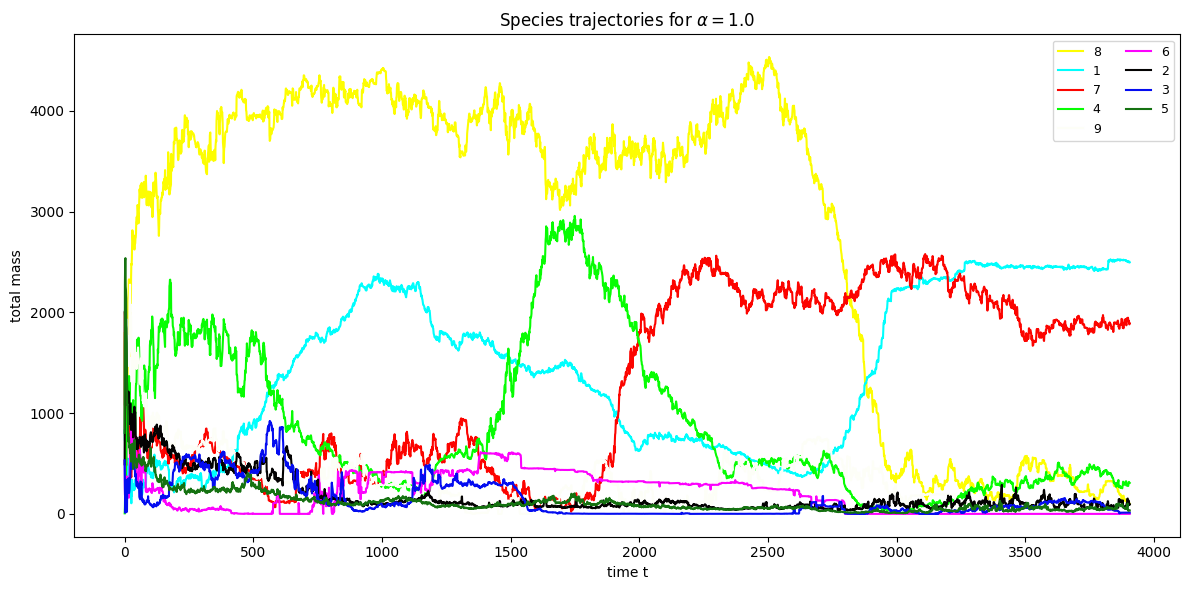

In [71]:
em.plot_mass_trajectories(masses_T, palette=palette, include_void=False, top_k=12,
                           mass_floor=0.0, logy=False, figsize=(12, 6), title="Species trajectories for $\\alpha = 1.0$")

In [1]:
list(range(6, 0, -1))

[6, 5, 4, 3, 2, 1]

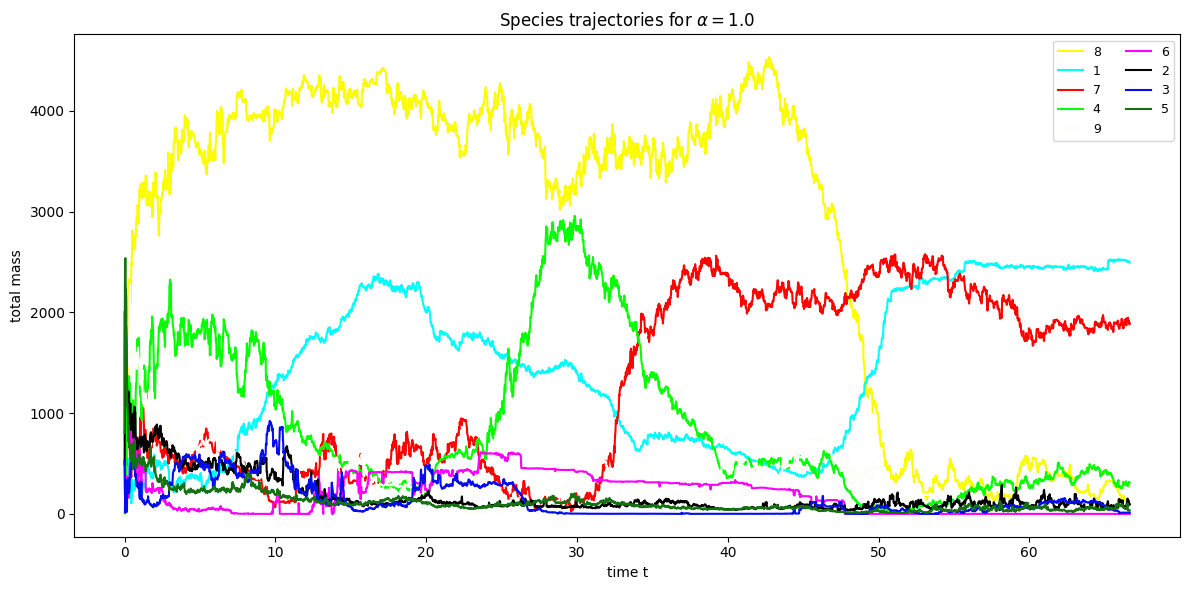

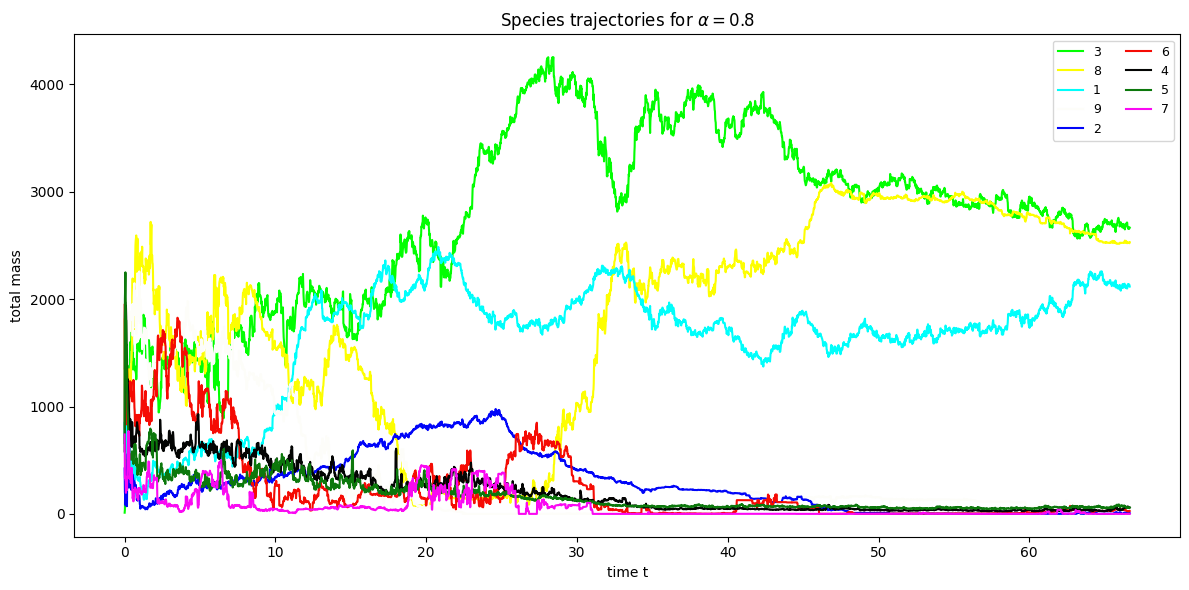

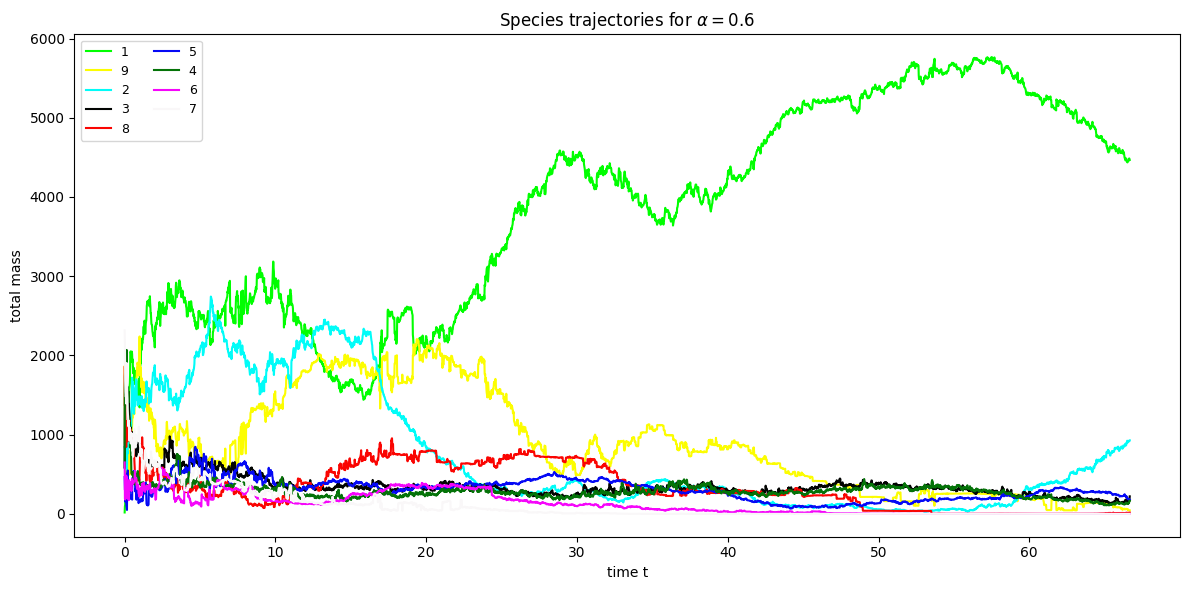

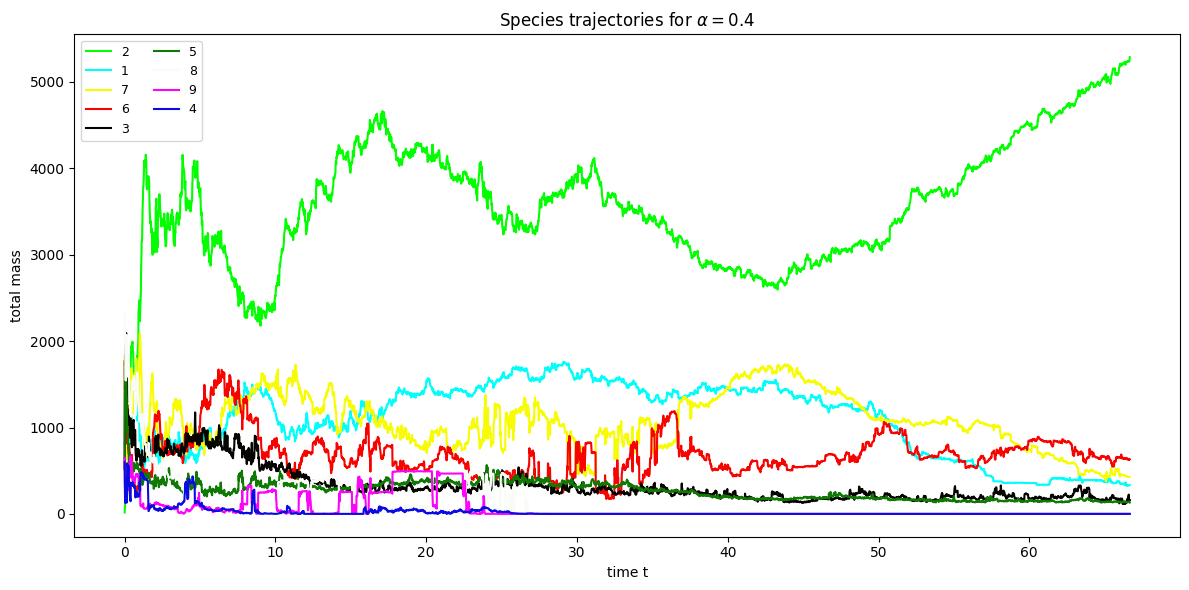

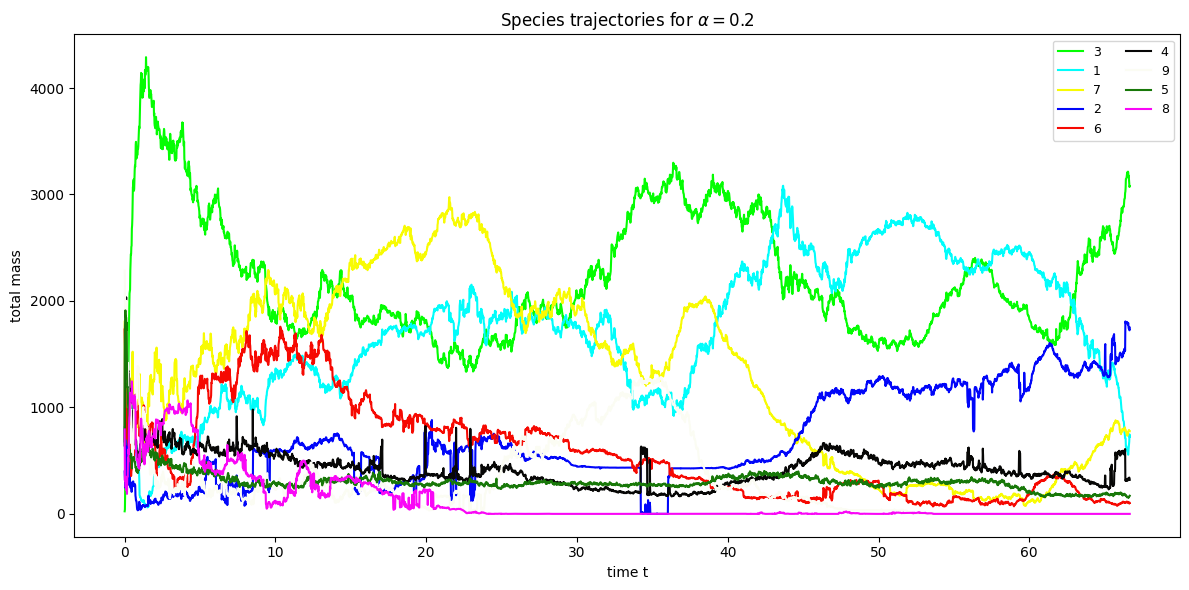

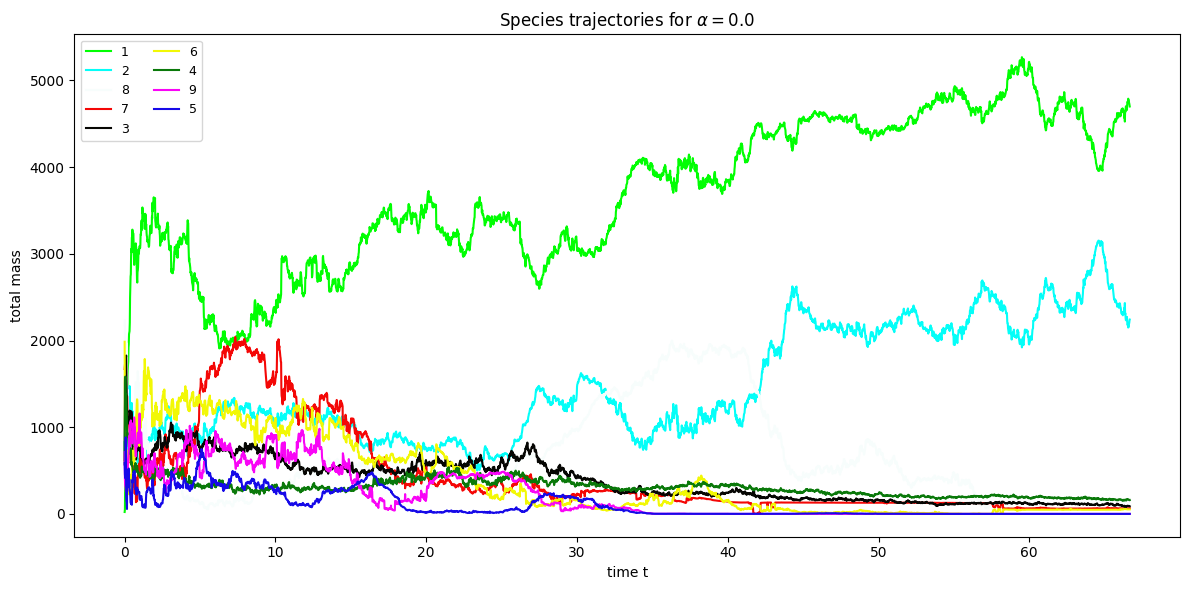

In [6]:
import scripts.evolutionary_metrics as em
for i in range(6, 0, -1):
    steps, P, A, rgb = sl.load_snapshots(
            f"data/interp_supervised_0_1/interp_{i}/snapshots_P",
            start_sec=0,
            end_sec=4000
        )
    A = A.sum(-1)
    masses_T, centers, palette, labels_T = em.compute_mass_trajectories(rgb, A,
                             q=4, min_bin_mass=0.0,
                             lam=200.0, dp_iters=8,
                             mass_eps_rel=1e-6, rgb_void=3, max_rgb_dist=0.0,
                             backend=None, return_labels=True)
    
    em.plot_mass_trajectories(masses_T, palette=palette, include_void=False, top_k=12,
                           mass_floor=0.0, logy=False, figsize=(12, 6), title=f"Species trajectories for $\\alpha = {(i-1) / 5}$")
    

ParameterReshaper: 110 parameters detected for optimization.


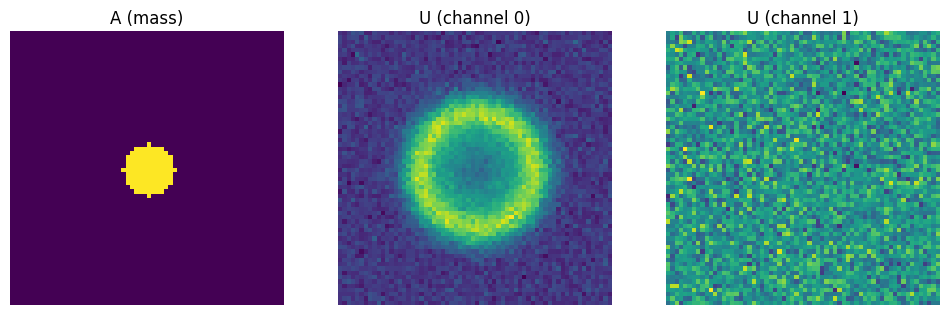

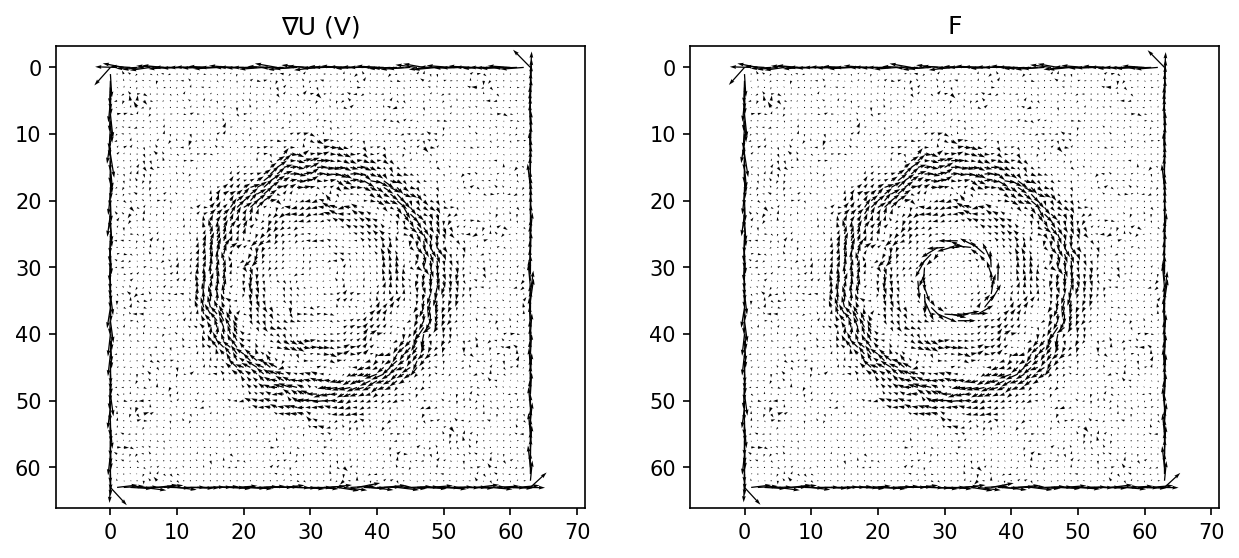

In [14]:
import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt

from substrates import create_substrate, FlattenSubstrateParameters
from substrates.lenia_flow.utils import growth, sobel

# ---------------------
# configs
# ---------------------
H = W = 64
C = 3
K = 9
seed = 0
mode = "circle"   # "circle" | "blob"
mass_radius = 6
mass_amount = 1.0
p_noise = 0.02

# ---------------------
# substrate + random params (K, g via default_params)
# ---------------------
fl = create_substrate(
    "lenia_flow",
    grid_size=H,
    C=C,
    k=K,
    dd=5,
    dt=0.2,
    sigma=0.65,
    border="wall",
    mix_rule="stoch",
)
fl = FlattenSubstrateParameters(fl)

rng = jax.random.PRNGKey(seed)
params = fl.default_params(rng)

# init a state just to get fK, m, s, cfg
state = fl.init_state(rng, params)
cfg = fl.substrate.cfg
fK = state["fK"]
m = state["m"]
s = state["s"]
c0 = cfg.c0
c1 = cfg.c1

# ---------------------
# build A and P
# ---------------------
A = jnp.zeros((H, W, C))
P = jnp.zeros((H, W, K))

# center coords
yy, xx = jnp.mgrid[0:H, 0:W]
cy, cx = H // 2, W // 2
rr = jnp.sqrt((yy - cy) ** 2 + (xx - cx) ** 2)

if mode == "circle":
    mask = (rr <= mass_radius).astype(jnp.float32)
else:
    # random connected blob by smoothing random field + threshold
    rng, kb = jax.random.split(rng)
    noise = jax.random.normal(kb, (H, W))
    # simple smoothing with box blur (3x3)
    # ---- smooth noise with wrap padding using lax.conv ----
    kernel = jnp.ones((3,3), dtype=jnp.float32) / 9.0

    # wrap padding
    noise_p = jnp.pad(noise, ((1,1),(1,1)), mode="wrap")
    # conv: input (N,H,W,C)
    noise_p = noise_p[None, ..., None]  # (1,H+2,W+2,1)
    ker = kernel[:, :, None, None]      # (3,3,1,1)

    sm = jax.lax.conv_general_dilated(
        noise_p,
        ker,
        window_strides=(1,1),
        padding="VALID",
        dimension_numbers=("NHWC", "HWIO", "NHWC"),
    )[0, ..., 0]

    noise = sm

    mask = (noise > jnp.percentile(noise, 85)).astype(jnp.float32)
    # keep only near center to ensure connected-ish
    mask = mask * (rr <= mass_radius * 2).astype(jnp.float32)

A = A.at[..., 0].set(mask * mass_amount)

# P init: one vector + tiny noise everywhere
rng, kp = jax.random.split(rng)
p_vec = jax.random.uniform(kp, (K,))
rng, kn = jax.random.split(rng)
P = p_vec[None, None, :] + p_noise * jax.random.normal(kn, (H, W, K))



# # --- warmup ---
# warmup_steps = 0

# def step(state, _rng):
#     next_state = fl.substrate.step_state(_rng, state, params)
#     return next_state, None

# rng, _rng = jax.random.split(rng)
# state, _ = jax.lax.scan(step, state, jax.random.split(_rng, warmup_steps))

# # дальше используй обновлённый state:
# A = state["A"]
# P = state["P"]
# fK = state["fK"]
# m = state["m"]
# s = state["s"]


# ---------------------
# compute U, ∇U (V), F
# ---------------------
# U (potential)
fA = jnp.fft.fft2(A, axes=(0, 1))
fAk = fA[:, :, c0]
U = jnp.real(jnp.fft.ifft2(fK * fAk, axes=(0, 1)))  # (H,W,K)

# growth
U = growth(U, m, s)
# apply P
U = U * P
# sum into channels
U = jnp.dstack([U[:, :, c1[c]].sum(axis=-1) for c in range(cfg.C)])  # (H,W,C)

# ∇U
V = sobel(U)  # (H,W,2,C)
C_grad = sobel(A.sum(axis=-1, keepdims=True))
alpha = jnp.clip((A[:, :, None, :] / 2) ** 2, 0.0, 1.0)
mag = cfg.dd - cfg.sigma
F = jnp.clip(V * (1 - alpha) - C_grad * alpha, -mag, mag)

# ---------------------
# plot
# ---------------------
fig, ax = plt.subplots(1, 3, figsize=(12, 4))
ax[0].imshow(A[..., 0])
ax[0].set_title("A (mass)")
ax[1].imshow(U[..., 0])
ax[1].set_title("U (channel 0)")
ax[2].imshow(U[..., 1] if C > 1 else U[..., 0])
ax[2].set_title("U (channel 1)")
for a in ax: a.axis("off")
plt.show()

# quiver plot for V and F (channel 0)
fig, ax = plt.subplots(1, 2, figsize=(10, 4), dpi=150)
ax[0].quiver(V[:, :, 0, 0]*10000, V[:, :, 1, 0]*10000)
ax[0].set_title("∇U (V)")
ax[0].invert_yaxis(); ax[0].axis("equal")

ax[1].quiver(F[:, :, 0, 0], F[:, :, 1, 0])
ax[1].set_title("F")
ax[1].invert_yaxis(); ax[1].axis("equal")
plt.show()



M. I. Katsnelson and V. Vanchurin,
Emergent quantumness in neural networks
FOUND PHYS 51, 94 (2021)